In [1]:
!pip install transformers datasets evaluate scikit-learn seaborn matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [2]:
from transformers import pipeline
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None
)

print("✅ Deep Emotion Classification Model Loaded")

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

✅ Deep Emotion Classification Model Loaded


In [4]:
text = "I am really excited about my new project!"

prediction = emotion_classifier(text)

print(prediction)

[[{'label': 'excitement', 'score': 0.8392684459686279}, {'label': 'joy', 'score': 0.052388690412044525}, {'label': 'neutral', 'score': 0.03589306026697159}, {'label': 'curiosity', 'score': 0.031609199941158295}, {'label': 'approval', 'score': 0.020879847928881645}, {'label': 'surprise', 'score': 0.019831905141472816}, {'label': 'admiration', 'score': 0.013843569904565811}, {'label': 'desire', 'score': 0.011631875298917294}, {'label': 'amusement', 'score': 0.010870483703911304}, {'label': 'gratitude', 'score': 0.010207652114331722}, {'label': 'love', 'score': 0.009625494480133057}, {'label': 'optimism', 'score': 0.006984084378927946}, {'label': 'confusion', 'score': 0.006978901103138924}, {'label': 'caring', 'score': 0.005472068674862385}, {'label': 'fear', 'score': 0.00546193728223443}, {'label': 'nervousness', 'score': 0.005048366263508797}, {'label': 'annoyance', 'score': 0.004687287379056215}, {'label': 'realization', 'score': 0.00415370287373662}, {'label': 'disapproval', 'score': 

In [5]:
top_prediction = max(
    prediction[0],
    key=lambda x: x["score"]
)

print("Emotion:", top_prediction["label"])
print("Confidence:", top_prediction["score"])

Emotion: excitement
Confidence: 0.8392684459686279


In [6]:
def predict_emotion(text):

    predictions = emotion_classifier(text)

    scores = predictions[0]

    top_prediction = max(
        scores,
        key=lambda x: x["score"]
    )

    return {
        "input_text": text,
        "emotion": top_prediction["label"],
        "confidence": round(top_prediction["score"] * 100, 2),
        "all_predictions": scores
    }

In [7]:
user_text = input("Enter your thoughts: ")

result = predict_emotion(user_text)

print("\n========== Prediction ==========")
print("Input:", result["input_text"])
print("Emotion:", result["emotion"])
print("Confidence:", result["confidence"], "%")

Enter your thoughts: i am feeling nothing

========== Prediction ==========
Input: i am feeling nothing
Emotion: neutral
Confidence: 66.32 %


In [8]:
dataset = load_dataset("google-research-datasets/go_emotions")

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

simplified/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  347kB            

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [9]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [10]:
print(dataset["test"][0])

{'text': 'I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!', 'labels': [25], 'id': 'eecwqtt'}


In [11]:
emotion_labels = dataset["test"].features["labels"].feature.names

print(emotion_labels)

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [12]:
import pandas as pd

test_data = dataset["test"]

texts = []
actual_labels = []

for item in test_data:

    # Keep only examples having exactly one emotion
    if len(item["labels"]) == 1:

        texts.append(item["text"])

        actual_labels.append(
            emotion_labels[item["labels"][0]]
        )

validation_df = pd.DataFrame({
    "text": texts,
    "actual_emotion": actual_labels
})

print(validation_df.head())
print("Total samples:", len(validation_df))

                                                text actual_emotion
0  I’m really sorry about your situation :( Altho...        sadness
1    It's wonderful because it's awful. At not with.     admiration
2  Kings fan here, good luck to you guys! Will be...     excitement
3  I didn't know that, thank you for teaching me ...      gratitude
4  They got bored from haunting earth for thousan...        neutral
Total samples: 4590


In [15]:
validation_df_small = validation_df.head(500).copy()

print("Samples for validation:", len(validation_df_small))

Samples for validation: 500


In [16]:
predicted_labels = []

for text in validation_df_small["text"]:

    prediction = emotion_classifier(text)

    top_prediction = max(
        prediction[0],
        key=lambda x: x["score"]
    )

    predicted_labels.append(
        top_prediction["label"]
    )

print("Predictions completed:", len(predicted_labels))

Predictions completed: 500


In [17]:
validation_df_small["predicted_emotion"] = predicted_labels

In [18]:
print(validation_df_small.head())

                                                text actual_emotion  \
0  I’m really sorry about your situation :( Altho...        sadness   
1    It's wonderful because it's awful. At not with.     admiration   
2  Kings fan here, good luck to you guys! Will be...     excitement   
3  I didn't know that, thank you for teaching me ...      gratitude   
4  They got bored from haunting earth for thousan...        neutral   

  predicted_emotion  
0           remorse  
1        admiration  
2          optimism  
3         gratitude  
4           neutral  


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    validation_df_small["actual_emotion"],
    validation_df_small["predicted_emotion"]
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 64.0 %


In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    validation_df_small["actual_emotion"],
    validation_df_small["predicted_emotion"]
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 64.0 %


In [22]:
labels = sorted(
    validation_df_small["actual_emotion"].unique()
)

cm = confusion_matrix(
    validation_df_small["actual_emotion"],
    validation_df_small["predicted_emotion"],
    labels=labels
)

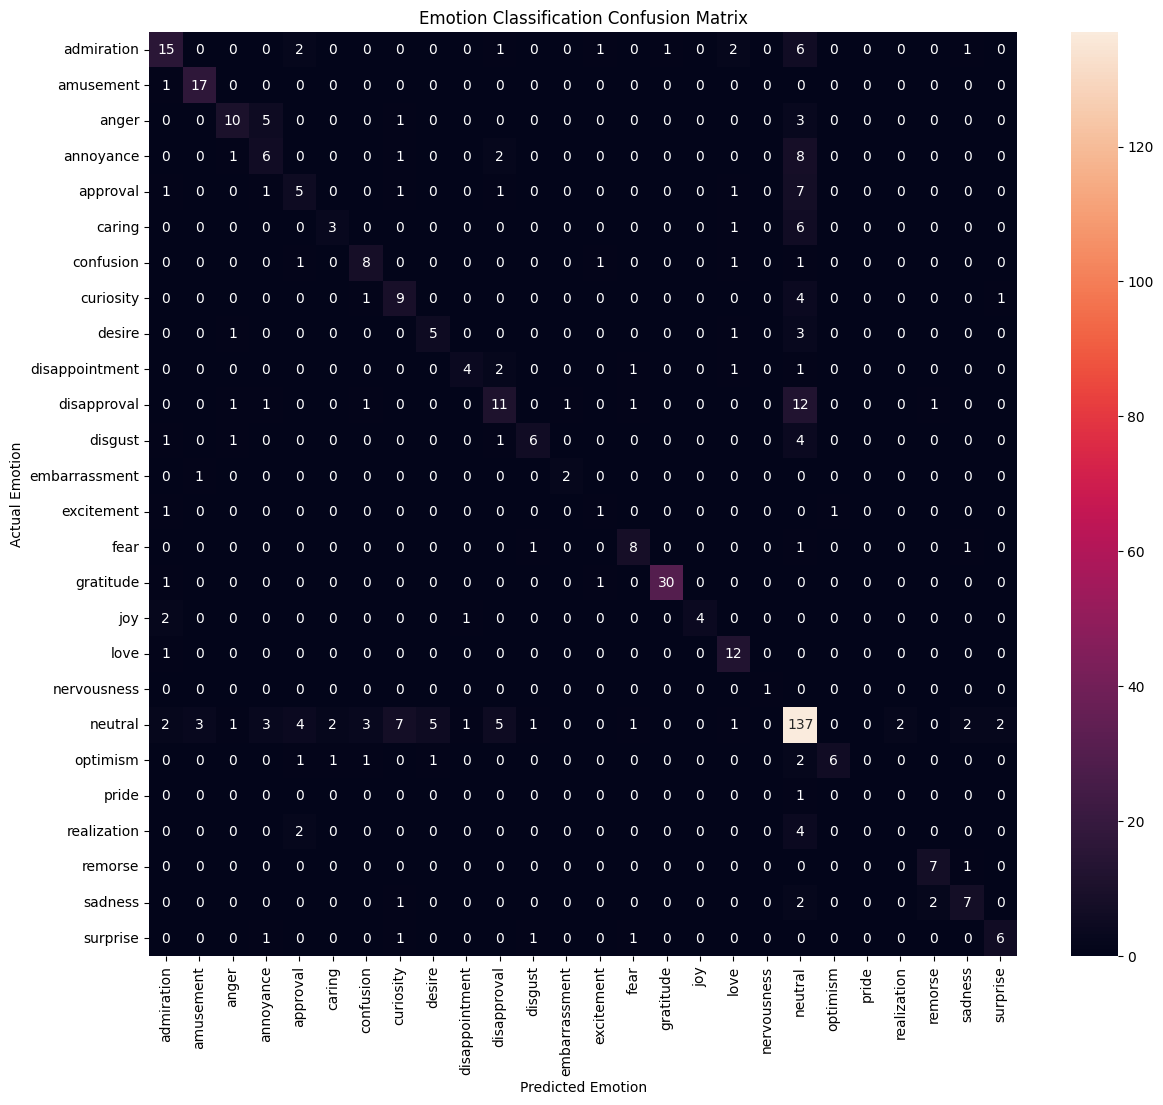

In [23]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Emotion Classification Confusion Matrix")

plt.show()

In [24]:
test_sentences = [
    "I got selected for the internship and I am so excited!",
    "I feel lonely and nobody understands me.",
    "I am worried about my exams tomorrow.",
    "My friend betrayed me and I am really angry.",
    "Everything is going well today.",
    "I don't know what to do about this situation."
]

In [25]:
for text in test_sentences:

    result = predict_emotion(text)

    print("\nText:", text)
    print("Emotion:", result["emotion"])
    print("Confidence:", result["confidence"], "%")


Text: I got selected for the internship and I am so excited!
Emotion: excitement
Confidence: 83.7 %

Text: I feel lonely and nobody understands me.
Emotion: sadness
Confidence: 86.7 %

Text: I am worried about my exams tomorrow.
Emotion: nervousness
Confidence: 55.02 %

Text: My friend betrayed me and I am really angry.
Emotion: anger
Confidence: 83.53 %

Text: Everything is going well today.
Emotion: approval
Confidence: 52.59 %

Text: I don't know what to do about this situation.
Emotion: confusion
Confidence: 93.24 %


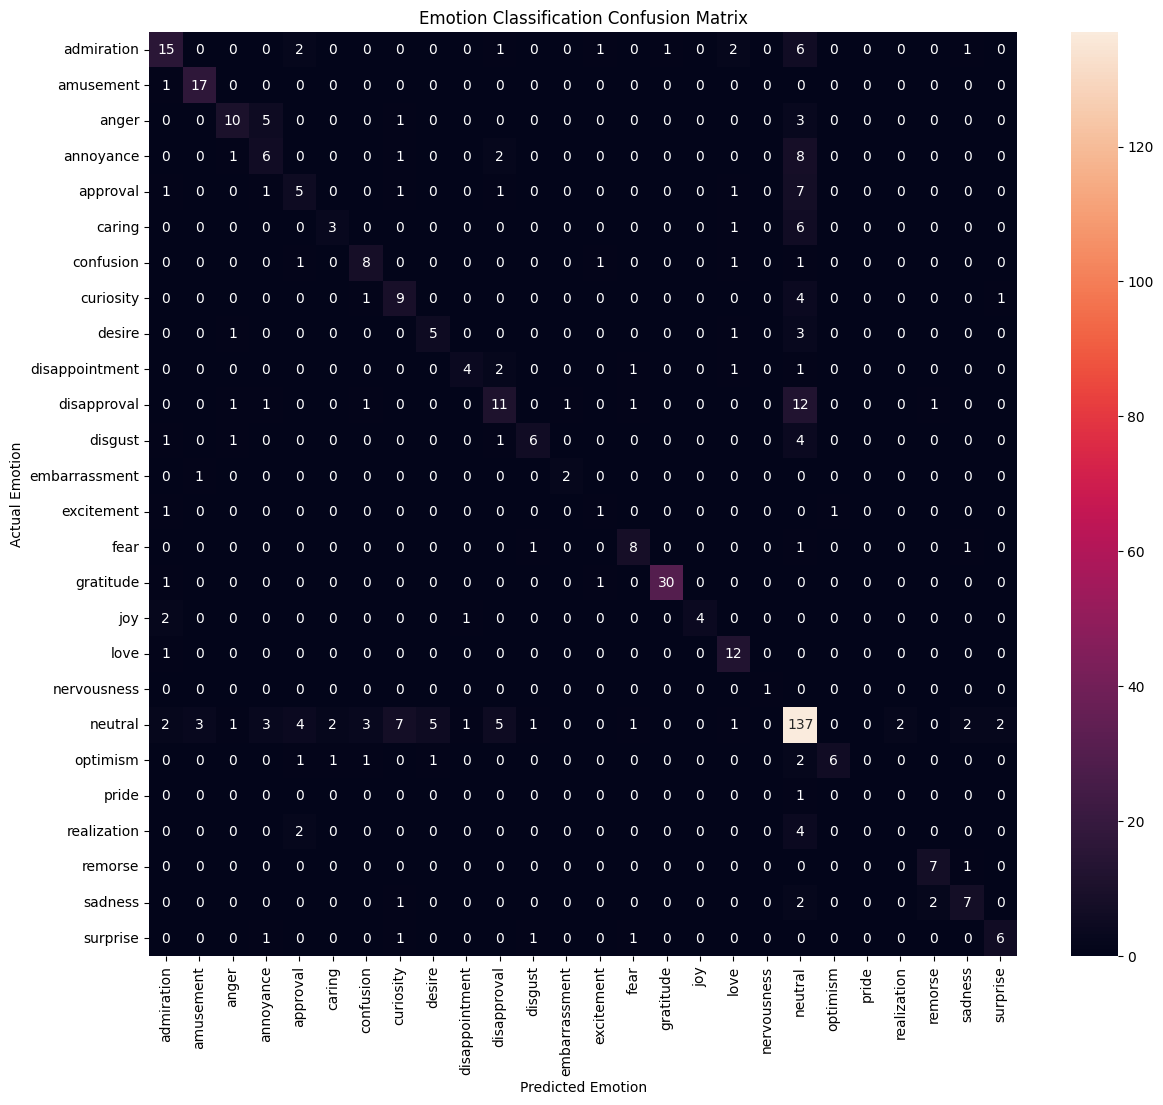

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(
    validation_df_small["actual_emotion"].unique()
)

cm = confusion_matrix(
    validation_df_small["actual_emotion"],
    validation_df_small["predicted_emotion"],
    labels=labels
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Emotion Classification Confusion Matrix")

plt.show()

In [27]:
wrong_predictions = validation_df_small[
    validation_df_small["actual_emotion"] !=
    validation_df_small["predicted_emotion"]
]

print("Total incorrect predictions:", len(wrong_predictions))

print(
    wrong_predictions[
        ["text", "actual_emotion", "predicted_emotion"]
    ].head(20)
)

Total incorrect predictions: 180
                                                 text  actual_emotion  \
0   I’m really sorry about your situation :( Altho...         sadness   
2   Kings fan here, good luck to you guys! Will be...      excitement   
7                     100%! Congrats on your job too!       gratitude   
12  I never wanted to punch osap harder after seei...     disapproval   
13  The thought of shooting anything at asylum see...            fear   
22  Same here but it seems like that will make it ...         neutral   
25  What's that like? Like what's the thought proc...         neutral   
29  I totally thought the same thing! I was like, ...         neutral   
31  I like to bring up the fact that all of these ...         neutral   
32                    You didn't watch it to the end.     disapproval   
33  please dont bring a woman in as a sex toy for ...          caring   
36  Despite having lived here for 10 years, i've n...         neutral   
40              OP

In [28]:
error_counts = (
    wrong_predictions["actual_emotion"]
    .value_counts()
)

print(error_counts)

actual_emotion
neutral           45
disapproval       18
admiration        14
annoyance         12
approval          12
anger              9
disgust            7
caring             7
curiosity          6
optimism           6
realization        6
sadness            5
desire             5
disappointment     5
confusion          4
surprise           4
fear               3
joy                3
excitement         2
gratitude          2
embarrassment      1
pride              1
remorse            1
love               1
amusement          1
Name: count, dtype: int64


In [30]:
test_sentences = [
    "I got selected for the internship and I am so excited!",
    "I feel lonely and nobody understands me.",
    "I am worried about my exams tomorrow.",
    "My friend betrayed me and I am really angry.",
    "Everything is going well today.",
    "I don't know what to do about this situation.",
    "I am extremely grateful for my parents.",
    "I am embarrassed about what happened.",
    "I am confused about what I should do.",
    "I am proud of myself for completing this project."
]

for text in test_sentences:

    result = predict_emotion(text)

    print("\nText:", text)
    print("Emotion:", result["emotion"])
    print("Confidence:", result["confidence"], "%")


Text: I got selected for the internship and I am so excited!
Emotion: excitement
Confidence: 83.7 %

Text: I feel lonely and nobody understands me.
Emotion: sadness
Confidence: 86.7 %

Text: I am worried about my exams tomorrow.
Emotion: nervousness
Confidence: 55.02 %

Text: My friend betrayed me and I am really angry.
Emotion: anger
Confidence: 83.53 %

Text: Everything is going well today.
Emotion: approval
Confidence: 52.59 %

Text: I don't know what to do about this situation.
Emotion: confusion
Confidence: 93.24 %

Text: I am extremely grateful for my parents.
Emotion: gratitude
Confidence: 99.07 %

Text: I am embarrassed about what happened.
Emotion: embarrassment
Confidence: 77.53 %

Text: I am confused about what I should do.
Emotion: confusion
Confidence: 93.89 %

Text: I am proud of myself for completing this project.
Emotion: pride
Confidence: 48.79 %


In [31]:
for text in test_sentences:

    result = predict_emotion(text)

    print("\nText:", text)
    print("Emotion:", result["emotion"])
    print("Confidence:", result["confidence"], "%")

    print("Top 3 predictions:")

    for prediction in result["all_predictions"][:3]:
        print(
            prediction["label"],
            "→",
            round(prediction["score"] * 100, 2),
            "%"
        )


Text: I got selected for the internship and I am so excited!
Emotion: excitement
Confidence: 83.7 %
Top 3 predictions:
excitement → 83.7 %
joy → 6.13 %
neutral → 3.93 %

Text: I feel lonely and nobody understands me.
Emotion: sadness
Confidence: 86.7 %
Top 3 predictions:
sadness → 86.7 %
disappointment → 16.11 %
neutral → 2.83 %

Text: I am worried about my exams tomorrow.
Emotion: nervousness
Confidence: 55.02 %
Top 3 predictions:
nervousness → 55.02 %
fear → 28.03 %
caring → 9.7 %

Text: My friend betrayed me and I am really angry.
Emotion: anger
Confidence: 83.53 %
Top 3 predictions:
anger → 83.53 %
annoyance → 12.63 %
neutral → 5.71 %

Text: Everything is going well today.
Emotion: approval
Confidence: 52.59 %
Top 3 predictions:
approval → 52.59 %
neutral → 25.88 %
optimism → 11.91 %

Text: I don't know what to do about this situation.
Emotion: confusion
Confidence: 93.24 %
Top 3 predictions:
confusion → 93.24 %
neutral → 4.8 %
disapproval → 3.84 %

Text: I am extremely grateful f